## Clean Data

In [1]:
from pathlib import Path
import pandas as pd

# Notebook is in: .../iaqf_analysis/stablecoin_dynamics/notebooks
NOTEBOOK_DIR = Path.cwd()

# Project root should be: .../iaqf_analysis
ROOT = NOTEBOOK_DIR.parents[1]

DATA_BINANCE_RAW = ROOT / "data" / "binance" / "raw"

print("notebook_dir:", NOTEBOOK_DIR)
print("root:", ROOT)
print("data_binance_raw:", DATA_BINANCE_RAW)
print("exists:", DATA_BINANCE_RAW.exists())
print("csv files:", [p.name for p in sorted(DATA_BINANCE_RAW.glob("*.csv"))])


notebook_dir: /Users/liucanxin/Documents/GitHub/iaqf_analysis/stablecoin_dynamics/code
root: /Users/liucanxin/Documents/GitHub/iaqf_analysis
data_binance_raw: /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw
exists: True
csv files: ['BTCUSDC_1m_20230301_20230321.csv', 'BTCUSDT_1m_20230301_20230321.csv', 'BTCUSD_1m_20230301_20230321.csv', 'metadata_range_1m_20230301_20230321.csv']


In [2]:
# Update filenames here if your repo changes them
files_b = {
    "btc_usdt": DATA_BINANCE_RAW / "BTCUSDT_1m_20230301_20230321.csv",
    "btc_usdc": DATA_BINANCE_RAW / "BTCUSDC_1m_20230301_20230321.csv",
    "btc_usd":  DATA_BINANCE_RAW / "BTCUSD_1m_20230301_20230321.csv",
}

# Sanity: make sure files exist
for k, p in files_b.items():
    print(k, "->", p, "| exists:", p.exists())

data_b = {k: pd.read_csv(p) for k, p in files_b.items()}

for k, df in data_b.items():
    print(k, df.shape)
    print(df.head(2))


btc_usdt -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSDT_1m_20230301_20230321.csv | exists: True
btc_usdc -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSDC_1m_20230301_20230321.csv | exists: True
btc_usd -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSD_1m_20230301_20230321.csv | exists: True
btc_usdt (30240, 6)
                   open_time      open      high       low     close    volume
0  2023-03-01 00:00:00+00:00  23140.48  23150.77  23128.52  23142.31  2.131777
1  2023-03-01 00:01:00+00:00  23143.89  23148.80  23137.61  23137.77  0.881378
btc_usdc (30240, 6)
                   open_time      open      high       low     close   volume
0  2023-03-01 00:00:00+00:00  23143.82  23152.65  23140.02  23152.65  0.26395
1  2023-03-01 00:01:00+00:00  23152.65  23152.65  23152.65  23152.65  0.00000
btc_usd (30240, 6)
                   open_time      open      high       low     close    volume
0  2023-03-01 00:0

In [3]:
# Update filenames here if your repo changes them
files_b = {
    "btc_usdt": DATA_BINANCE_RAW / "BTCUSDT_1m_20230301_20230321.csv",
    "btc_usdc": DATA_BINANCE_RAW / "BTCUSDC_1m_20230301_20230321.csv",
    "btc_usd":  DATA_BINANCE_RAW / "BTCUSD_1m_20230301_20230321.csv",
}

# Sanity: make sure files exist
for k, p in files_b.items():
    print(k, "->", p, "| exists:", p.exists())

data_b = {k: pd.read_csv(p) for k, p in files_b.items()}

for k, df in data_b.items():
    print(k, df.shape)
    print(df.head(2))


btc_usdt -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSDT_1m_20230301_20230321.csv | exists: True
btc_usdc -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSDC_1m_20230301_20230321.csv | exists: True
btc_usd -> /Users/liucanxin/Documents/GitHub/iaqf_analysis/data/binance/raw/BTCUSD_1m_20230301_20230321.csv | exists: True
btc_usdt (30240, 6)
                   open_time      open      high       low     close    volume
0  2023-03-01 00:00:00+00:00  23140.48  23150.77  23128.52  23142.31  2.131777
1  2023-03-01 00:01:00+00:00  23143.89  23148.80  23137.61  23137.77  0.881378
btc_usdc (30240, 6)
                   open_time      open      high       low     close   volume
0  2023-03-01 00:00:00+00:00  23143.82  23152.65  23140.02  23152.65  0.26395
1  2023-03-01 00:01:00+00:00  23152.65  23152.65  23152.65  23152.65  0.00000
btc_usd (30240, 6)
                   open_time      open      high       low     close    volume
0  2023-03-01 00:0

Robust timestamp parser + cleaner

In [4]:
import pandas as pd

def parse_time_column(s: pd.Series) -> pd.Series:
    """
    Robust timestamp parser:
    - If numeric -> treat as milliseconds since epoch
    - Otherwise -> parse as datetime string (keeps timezone if present)
    """
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().mean() > 0.8:   # mostly numeric => ms epoch
        ts = pd.to_datetime(s_num, unit="ms", utc=True)
    else:
        ts = pd.to_datetime(s, utc=True, errors="coerce")
    return ts

def prepare_price_series(df: pd.DataFrame, label: str) -> pd.Series:
    """
    Returns a close-price series indexed by timestamp (sorted),
    with duplicate timestamps deduped.
    """
    out = df.copy()

    # Pick time column that exists
    time_col_candidates = ["open_time", "timestamp", "time", "openTime"]
    time_col = next((c for c in time_col_candidates if c in out.columns), None)
    if time_col is None:
        raise ValueError(f"[{label}] No timestamp column found. Columns={list(out.columns)}")

    if "close" not in out.columns:
        raise ValueError(f"[{label}] No 'close' column found. Columns={list(out.columns)}")

    out["timestamp"] = parse_time_column(out[time_col])
    out = out.dropna(subset=["timestamp"])

    out = out[["timestamp", "close"]].copy()
    out = out.sort_values("timestamp")
    out = out.drop_duplicates(subset=["timestamp"], keep="last")

    # ensure close is numeric
    out["close"] = pd.to_numeric(out["close"], errors="coerce")
    out = out.dropna(subset=["close"])

    return out.set_index("timestamp")["close"].rename(label)


In [5]:
p_btc_usdt_b = prepare_price_series(data_b["btc_usdt"], "p_btc_usdt_b")
p_btc_usdc_b = prepare_price_series(data_b["btc_usdc"], "p_btc_usdc_b")
p_btc_usd_b  = prepare_price_series(data_b["btc_usd"],  "p_btc_usd_b")

prices_b = pd.concat([p_btc_usdt_b, p_btc_usdc_b, p_btc_usd_b], axis=1)

print("Rows total (union of timestamps):", len(prices_b))
print("Missing counts per column:")
print(prices_b.isna().sum())

complete_b = prices_b.dropna()
print("\nRows with all three present (intersection):", len(complete_b))

missing_any = prices_b[prices_b.isna().any(axis=1)]
print("\nExample timestamps with missing data (first 10):")
print(missing_any.head(10))

prices_b_clean = complete_b.copy()
print("\nClean panel time range:", prices_b_clean.index.min(), "to", prices_b_clean.index.max())
print("Clean panel shape:", prices_b_clean.shape)


Rows total (union of timestamps): 30240
Missing counts per column:
p_btc_usdt_b    0
p_btc_usdc_b    0
p_btc_usd_b     0
dtype: int64

Rows with all three present (intersection): 30240

Example timestamps with missing data (first 10):
Empty DataFrame
Columns: [p_btc_usdt_b, p_btc_usdc_b, p_btc_usd_b]
Index: []

Clean panel time range: 2023-03-01 00:00:00+00:00 to 2023-03-21 23:59:00+00:00
Clean panel shape: (30240, 3)


## 1.1 Stablecoin Basis (Binance, 1-Minute Data)

### Objective
This section measures whether stablecoin-quoted BTC spot markets trade at a **premium or discount** relative to the **USD-quoted** BTC spot market on the **same exchange (Binance)**.

---

### Data preparation (what we did)
We load 1-minute spot **close** prices from Binance for three markets:

- $P_{\mathrm{BTC/USDT},b}(t)$ : BTC price quoted in USDT on Binance  
- $P_{\mathrm{BTC/USDC},b}(t)$ : BTC price quoted in USDC on Binance  
- $P_{\mathrm{BTC/USD},b}(t)$  : BTC price quoted in USD on Binance  

Then we:

1. Parse timestamps into a unified **UTC** datetime index
2. Sort and deduplicate timestamps
3. Align the three series on the **common intersection of timestamps** (drop any minute where one market is missing)

After cleaning, we work with a **balanced panel** where all three prices exist at each timestamp.

---

### Definition: Stablecoin basis (Binance)

**USDT basis**
$$
\mathrm{Basis}_{\mathrm{USDT},b}(t)
=
\frac{P_{\mathrm{BTC/USDT},b}(t)-P_{\mathrm{BTC/USD},b}(t)}
     {P_{\mathrm{BTC/USD},b}(t)}
$$

**USDC basis**
$$
\mathrm{Basis}_{\mathrm{USDC},b}(t)
=
\frac{P_{\mathrm{BTC/USDC},b}(t)-P_{\mathrm{BTC/USD},b}(t)}
     {P_{\mathrm{BTC/USD},b}(t)}
$$

These are **unitless relative price deviations** (fractions of the USD BTC price), so they are directly comparable across time and (later) across exchanges.

---

### Interpretation (how to read the numbers)

- **Positive basis** ($>0$):  
  BTC is **more expensive** when quoted in that stablecoin than in USD.  
  Equivalent interpretation: **the stablecoin is at a relative discount vs USD** (you need *more* stablecoin per BTC), or there is stronger demand / more friction on that stablecoin rail.

- **Negative basis** ($<0$):  
  BTC is **cheaper** when quoted in that stablecoin than in USD.  
  Equivalent interpretation: **the stablecoin is at a relative premium vs USD** (you need *less* stablecoin per BTC), or USD-side frictions make USD quotes relatively higher.

- **Magnitude**:  
  Larger absolute values mean a larger deviation from parity (stronger “stress / confidence / friction” signal).

---

### Economic meaning
The stablecoin basis captures how much the market is willing to pay (or accept) for BTC when settlement occurs via a **stablecoin rail** rather than **USD**. Persistent or asymmetric basis behavior may reflect:

- differences in perceived **counterparty / redemption risk**
- **liquidity frictions** between fiat and stablecoin rails
- shifts in **market confidence** during calm vs stress periods


In [6]:
p_usdt = prices_b_clean["p_btc_usdt_b"]
p_usdc = prices_b_clean["p_btc_usdc_b"]
p_usd  = prices_b_clean["p_btc_usd_b"]

basis_usdt_b = ((p_usdt - p_usd) / p_usd).rename("basis_usdt_b")
basis_usdc_b = ((p_usdc - p_usd) / p_usd).rename("basis_usdc_b")

print("basis_usdt_b describe:\n", basis_usdt_b.describe())
print("\nbasis_usdc_b describe:\n", basis_usdc_b.describe())
print("\nCorrelation (USDT vs USDC basis):", basis_usdt_b.corr(basis_usdc_b))


basis_usdt_b describe:
 count    30240.000000
mean        -0.002011
std          0.002594
min         -0.016317
25%         -0.003157
50%         -0.001260
75%         -0.000025
max          0.003071
Name: basis_usdt_b, dtype: float64

basis_usdc_b describe:
 count    30240.000000
mean         0.005119
std          0.016814
min         -0.006575
25%         -0.000096
50%          0.000216
75%          0.001035
max          0.143075
Name: basis_usdc_b, dtype: float64

Correlation (USDT vs USDC basis): -0.5848506839592437


## 1.2 Cross-Stablecoin Spread (Relative Confidence)

### Objective
This section isolates **relative pricing / confidence** between **USDT** and **USDC** by differencing their basis series.
Because both bases use the same **BTC-USD** benchmark, the difference removes BTC-level moves and leaves a “**USDT vs USDC**” signal.

---

### Definition: Cross-stablecoin spread (Binance)

**USDT vs USDC spread**
$$
\mathrm{Spread}_{\mathrm{USDT-USDC},b}(t)
=
\mathrm{Basis}_{\mathrm{USDT},b}(t)
-
\mathrm{Basis}_{\mathrm{USDC},b}(t)
$$

This spread is a **unitless relative deviation** (difference of two unitless bases), so it is directly comparable across time.

---

### Interpretation (how to read the numbers)

- **Positive spread** ($>0$):  
  USDT basis is higher than USDC basis  
  $\Rightarrow$ BTC is relatively more expensive in **USDT** than in **USDC**  
  $\Rightarrow$ implies **USDT is weaker** relative to USDC (or **USDC is stronger**)

- **Negative spread** ($<0$):  
  BTC is relatively more expensive in **USDC** than in **USDT**  
  $\Rightarrow$ implies **USDC is weaker** relative to USDT (or **USDT is stronger**)

- **Magnitude**:  
  Larger absolute values mean a larger **relative divergence** in stablecoin pricing (stronger “confidence / stress / friction” signal between the two stablecoin rails).

---

### Why this is useful
- Removes BTC-level noise shared by both series  
- Focuses on **relative stablecoin pricing** rather than overall crypto moves  
- Helps interpret “which stablecoin loses the peg more?” and connect to news/regulation/confidence narratives


Compute pread + summary table

In [7]:
spread_usdt_usdc_b = (basis_usdt_b - basis_usdc_b).rename("spread_usdt_usdc_b")

measures_12_b = pd.concat([basis_usdt_b, basis_usdc_b, spread_usdt_usdc_b], axis=1)

print("1.2 measures shape:", measures_12_b.shape)
print(measures_12_b.head())
print("\nMissing values (should be 0):")
print(measures_12_b.isna().sum())


1.2 measures shape: (30240, 3)
                           basis_usdt_b  basis_usdc_b  spread_usdt_usdc_b
timestamp                                                                
2023-03-01 00:00:00+00:00     -0.000061      0.000386           -0.000447
2023-03-01 00:01:00+00:00     -0.000255      0.000388           -0.000643
2023-03-01 00:02:00+00:00     -0.000112     -0.000146            0.000034
2023-03-01 00:03:00+00:00      0.000060     -0.000181            0.000241
2023-03-01 00:04:00+00:00      0.000003     -0.000210            0.000212

Missing values (should be 0):
basis_usdt_b          0
basis_usdc_b          0
spread_usdt_usdc_b    0
dtype: int64


Frequency + tail events (and top moves)

In [8]:
# Frequency of positive vs negative spread
pos_share = (spread_usdt_usdc_b > 0).mean()
neg_share = (spread_usdt_usdc_b < 0).mean()
zero_share = (spread_usdt_usdc_b == 0).mean()

print(f"Spread > 0 share:  {pos_share:.4f}")
print(f"Spread < 0 share:  {neg_share:.4f}")
print(f"Spread = 0 share:  {zero_share:.4f}")

# Tail event thresholds (absolute)
abs_spread = spread_usdt_usdc_b.abs()
q95 = abs_spread.quantile(0.95)
q99 = abs_spread.quantile(0.99)

print("\nAbsolute spread thresholds:")
print(f"95% quantile: {q95:.6f}  ({q95*1e4:.2f} bps)")
print(f"99% quantile: {q99:.6f}  ({q99*1e4:.2f} bps)")

# Largest events (top 10 absolute)
top_events = measures_12_b.assign(abs_spread=abs_spread).sort_values("abs_spread", ascending=False).head(10)
top_events


Spread > 0 share:  0.2174
Spread < 0 share:  0.7823
Spread = 0 share:  0.0003

Absolute spread thresholds:
95% quantile: 0.049203  (492.03 bps)
99% quantile: 0.102883  (1028.83 bps)


,basis_usdt_b,basis_usdc_b,spread_usdt_usdc_b,abs_spread
timestamp,,,,
2023-03-11 07:50:00+00:00,-0.006408,0.143075,-0.149483,0.149483
2023-03-11 07:49:00+00:00,-0.006128,0.142138,-0.148266,0.148266
2023-03-11 07:48:00+00:00,-0.006500,0.138216,-0.144716,0.144716
2023-03-11 07:59:00+00:00,-0.005907,0.137475,-0.143382,0.143382
2023-03-11 07:46:00+00:00,-0.006858,0.135756,-0.142613,0.142613
2023-03-11 08:00:00+00:00,-0.005732,0.136865,-0.142597,0.142597
2023-03-11 07:52:00+00:00,-0.006273,0.133056,-0.139328,0.139328
2023-03-11 07:54:00+00:00,-0.005769,0.133299,-0.139068,0.139068
2023-03-11 07:47:00+00:00,-0.006277,0.132244,-0.138521,0.138521


## 1.3 Absolute Deviation Magnitude

### Objective
While Sections 1.1 and 1.2 focus on the **direction** of stablecoin pricing deviations (premium vs discount, relative confidence),
this section focuses on the **magnitude** of deviations **regardless of sign**.

The goal is to measure **how far prices move away from parity**, not which side they move to.

---

### Definition: Absolute basis deviation

For any basis series $\mathrm{Basis}(t)$, define its absolute deviation as:

$$
\left| \mathrm{Basis}(t) \right|
$$

This transformation removes the sign and retains only the **distance from zero (parity)**.

---

### Measures used

We summarize absolute deviations using:

- **Mean Absolute Deviation (MAD)**  
  $$
  \mathrm{MAD} = \mathbb{E}\left[ \left| \mathrm{Basis}(t) \right| \right]
  $$

- **Tail percentiles** (95th and 99th):
  $$
  Q_{0.95}\left( \left| \mathrm{Basis}(t) \right| \right), \quad
  Q_{0.99}\left( \left| \mathrm{Basis}(t) \right| \right)
  $$

These statistics capture:
- *typical deviation size* (MAD)
- *extreme stress events* (upper tail behavior)

---

### Interpretation (how to read the numbers)

- **Higher MAD**  
  → Prices deviate more from parity on average  
  → Indicates weaker arbitrage efficiency or persistent frictions

- **Higher 95th / 99th percentiles**  
  → Larger extreme deviations during stress periods  
  → Indicates vulnerability to liquidity shocks, redemptions, or market stress

- **Comparison across exchanges**  
  Because the basis is unitless and normalized by the USD price, these magnitude measures are directly comparable:
  - across stablecoins (USDT vs USDC),
  - across time,
  - and across exchanges (in later sections).

---

### Economic meaning
Absolute deviation magnitude measures **how unstable the pricing relationship is**, independent of direction.

Large absolute deviations reflect:
- breakdowns in **arbitrage**
- **liquidity fragmentation** across rails
- temporary or persistent **market stress**
- exchange-specific frictions or operational constraints

---

### What this answers
This section directly answers:

- **“Are deviations larger on some exchanges?”**
- **“Where do stablecoin pricing frictions become most severe?”**
- **“Which markets experience the strongest tail stress?”**

These magnitude measures complement directional results from Sections 1.1–1.2 and help distinguish
**frequent small noise** from **rare but severe dislocations**.


In [9]:
# --- 1.3 Absolute Deviation Magnitude (MAD + tail percentiles) ---
# Assumes you already have:
#   basis_usdt_b, basis_usdc_b   (from 1.1)
# If not, this cell will rebuild them from prices_b_clean.

import numpy as np
import pandas as pd

# ----------------------------
# 0) Ensure inputs exist
# ----------------------------
need_prices = "prices_b_clean" in globals()
need_basis  = ("basis_usdt_b" in globals()) and ("basis_usdc_b" in globals())

if not need_basis:
    if not need_prices:
        raise NameError("Missing `prices_b_clean`. Re-run your 1.1 data alignment/cleaning cells first.")
    basis_usdt_b = (prices_b_clean["p_btc_usdt_b"] - prices_b_clean["p_btc_usd_b"]) / prices_b_clean["p_btc_usd_b"]
    basis_usdc_b = (prices_b_clean["p_btc_usdc_b"] - prices_b_clean["p_btc_usd_b"]) / prices_b_clean["p_btc_usd_b"]
    basis_usdt_b = basis_usdt_b.rename("basis_usdt_b")
    basis_usdc_b = basis_usdc_b.rename("basis_usdc_b")

# Make sure everything is aligned and clean
basis_df_b = pd.concat([basis_usdt_b, basis_usdc_b], axis=1).dropna()

# ----------------------------
# 1) Absolute deviations
# ----------------------------
abs_basis_b = basis_df_b.abs()
abs_basis_b.columns = ["abs_basis_usdt_b", "abs_basis_usdc_b"]

# ----------------------------
# 2) Summary stats (level + bps)  [UPDATED: add p25/p75 + IQR]
# ----------------------------
def summarize_abs(series: pd.Series) -> pd.Series:
    out = pd.Series({
        "mean_abs": series.mean(),
        "median_abs": series.median(),
        "p25": series.quantile(0.25),
        "p75": series.quantile(0.75),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
        "p95": series.quantile(0.95),
        "p99": series.quantile(0.99),
        "max": series.max(),
    })

    # Also report in bps (1 = 100%, so multiply by 1e4)
    out_bps = out * 1e4
    out_bps.index = [f"{k}_bps" for k in out.index]
    return pd.concat([out, out_bps])

summary_13_b = pd.concat(
    [
        summarize_abs(abs_basis_b["abs_basis_usdt_b"]).rename("USDT (Binance)"),
        summarize_abs(abs_basis_b["abs_basis_usdc_b"]).rename("USDC (Binance)"),
    ],
    axis=1,
).T

display(summary_13_b)

# ----------------------------
# 3) Quick “largest deviation minutes” (top 10)
# ----------------------------
top10_usdt = abs_basis_b["abs_basis_usdt_b"].sort_values(ascending=False).head(10).to_frame()
top10_usdc = abs_basis_b["abs_basis_usdc_b"].sort_values(ascending=False).head(10).to_frame()

print("Top 10 absolute deviation timestamps (USDT basis):")
display(top10_usdt.assign(abs_bps=top10_usdt.iloc[:, 0] * 1e4))

print("Top 10 absolute deviation timestamps (USDC basis):")
display(top10_usdc.assign(abs_bps=top10_usdc.iloc[:, 0] * 1e4))


,mean_abs,median_abs,p25,p75,iqr,p95,p99,max,mean_abs_bps,median_abs_bps,p25_bps,p75_bps,iqr_bps,p95_bps,p99_bps,max_bps
USDT (Binance),0.002080,0.001263,0.000132,0.003157,0.003024,0.007856,0.010617,0.016317,20.804410,12.62756,1.323144,31.567129,30.243985,78.563227,106.171684,163.17035
USDC (Binance),0.005376,0.000410,0.000156,0.001178,0.001023,0.040868,0.096788,0.143075,53.759333,4.10327,1.557491,11.783678,10.226187,408.678725,967.882446,1430.75196


Top 10 absolute deviation timestamps (USDT basis):


,abs_basis_usdt_b,abs_bps
timestamp,,
2023-03-12 19:52:00+00:00,0.016317,163.170350
2023-03-12 19:53:00+00:00,0.016205,162.050327
2023-03-12 19:54:00+00:00,0.016186,161.857630
2023-03-12 19:43:00+00:00,0.016082,160.822118
2023-03-12 19:55:00+00:00,0.015992,159.918417
2023-03-12 19:44:00+00:00,0.015852,158.516848
2023-03-12 19:41:00+00:00,0.015842,158.424047
2023-03-12 19:40:00+00:00,0.015839,158.387125
2023-03-12 19:56:00+00:00,0.015834,158.343570


Top 10 absolute deviation timestamps (USDC basis):


,abs_basis_usdc_b,abs_bps
timestamp,,
2023-03-11 07:50:00+00:00,0.143075,1430.751960
2023-03-11 07:49:00+00:00,0.142138,1421.380924
2023-03-11 07:48:00+00:00,0.138216,1382.161320
2023-03-11 07:59:00+00:00,0.137475,1374.754654
2023-03-11 08:00:00+00:00,0.136865,1368.650891
2023-03-11 07:46:00+00:00,0.135756,1357.555033
2023-03-11 07:54:00+00:00,0.133299,1332.990329
2023-03-11 07:52:00+00:00,0.133056,1330.556428
2023-03-11 07:47:00+00:00,0.132244,1322.437117


## 2.1 Volatility of Basis (Rolling)

### Goal
This section measures **how unstable** the stablecoin basis is over time.
If rolling volatility spikes, it indicates periods when the stablecoin-quoted BTC price deviates from the USD-quoted BTC price in a more **erratic / stressed** way.

### Objects from Section 1
We use the basis series (unitless relative deviations):

$$
\mathrm{Basis}_{\mathrm{USDT},e}(t)=\frac{P_{\mathrm{BTC/USDT},e}(t)-P_{\mathrm{BTC/USD},e}(t)}{P_{\mathrm{BTC/USD},e}(t)}
$$

$$
\mathrm{Basis}_{\mathrm{USDC},e}(t)=\frac{P_{\mathrm{BTC/USDC},e}(t)-P_{\mathrm{BTC/USD},e}(t)}{P_{\mathrm{BTC/USD},e}(t)}
$$

### Rolling volatility definition
For a trailing window length \(k\) (minutes for 1-minute data), rolling volatility is the rolling standard deviation:

$$
\sigma_{\mathrm{basis},e}(t;k)=\mathrm{StdDev}\Big(\mathrm{Basis}_e(t-k+1),\ldots,\mathrm{Basis}_e(t)\Big)
$$

We compute this separately for USDT and USDC:

$$
\sigma_{\mathrm{USDT},e}(t;k)=\mathrm{StdDev}\Big(\mathrm{Basis}_{\mathrm{USDT},e}(t-k+1),\ldots,\mathrm{Basis}_{\mathrm{USDT},e}(t)\Big)
$$

$$
\sigma_{\mathrm{USDC},e}(t;k)=\mathrm{StdDev}\Big(\mathrm{Basis}_{\mathrm{USDC},e}(t-k+1),\ldots,\mathrm{Basis}_{\mathrm{USDC},e}(t)\Big)
$$

### Interpretation (how to read the number)
- Higher \( \sigma \)  \(\Rightarrow\) deviations are **more volatile / less stable** in that window  
- Lower \( \sigma \) \(\Rightarrow\) deviations are **more stable** (even if the level is not zero)  
- Compare **USDT vs USDC**: which stablecoin basis is more “twitchy”  
- Compare **Binance vs Kraken**: which exchange shows more unstable stablecoin pricing

### Units and scaling
Rolling volatility is still **unitless** (standard deviation of a fraction).  
For readability we report it in **basis points (bps)**:

$$
\sigma_{\mathrm{bps}} = 10{,}000 \times \sigma
$$

Example: \(0.00010 \approx 1\) bp.


In [10]:
import pandas as pd

windows = [60, 360, 1440]  # 1h, 6h, 1d if data is 1-min
assets = {
    "USDT (Binance)": basis_usdt_b,
    "USDC (Binance)": basis_usdc_b,
}

def summarize_vol(series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean": series.mean(),
        "p25": series.quantile(0.25),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p99": series.quantile(0.99),
        "max": series.max(),
    })

vol_tables = []

for w in windows:
    rows = []
    for name, basis in assets.items():
        vol = basis.rolling(w).std()
        stats = summarize_vol(vol)
        stats.name = name
        rows.append(stats)

    table = pd.DataFrame(rows)
    table.insert(0, "window", w)
    vol_tables.append(table)

vol_summary_b = pd.concat(vol_tables)

display(vol_summary_b)

,window,mean,p25,p75,p90,p99,max
USDT (Binance),60,0.000275,0.000131,0.000340,0.000486,0.001087,0.001689
USDC (Binance),60,0.000990,0.000327,0.000875,0.001658,0.010820,0.043474
USDT (Binance),360,0.000467,0.000143,0.000543,0.000991,0.002578,0.002873
USDC (Binance),360,0.001849,0.000351,0.000994,0.002793,0.026072,0.042449
USDT (Binance),1440,0.000758,0.000157,0.000964,0.002121,0.003872,0.004037
USDC (Binance),1440,0.003879,0.000346,0.001159,0.012165,0.045772,0.047547


## 2.2 Mean Reversion Speed (Half-Life)

### Goal
Quantify how quickly the **stablecoin basis** returns toward its typical level after a deviation.

### Model (AR(1))
We fit an AR(1) model to the basis series:

$$
\text{Basis}(t) = \alpha + \phi\,\text{Basis}(t-1) + \varepsilon_t
$$

- $\phi$ measures **persistence**:
  - If $|\phi|$ is close to 1, shocks decay slowly (sticky dislocations).
  - If $|\phi|$ is small, shocks decay quickly (fast arbitrage / fast correction).

### Half-life
If $0 < \phi < 1$, the **half-life** (time for a shock to decay by 50%) is:

$$
\text{Half-life} = \frac{\ln(0.5)}{\ln(\phi)}
$$

We report half-life in:
- **minutes** (since the data are 1-minute bars)
- optionally **hours** or **days** for readability.

### Interpretation (how to read the number)
- **Short half-life** $\Rightarrow$ deviations correct quickly (strong arbitrage / higher confidence)
- **Long half-life** $\Rightarrow$ deviations persist (market frictions / stress / slower arbitrage)

This answers:
- “Which market/stablecoin reverts faster?”
- “Are deviations more persistent on certain platforms?”


Ensure basis exists (safe re-define):

In [11]:
import numpy as np
import pandas as pd

# --- Ensure Binance basis series exist ---
# Requires: prices_b_clean with columns p_btc_usdt_b, p_btc_usdc_b, p_btc_usd_b
if "basis_usdt_b" not in globals() or "basis_usdc_b" not in globals():
    if "prices_b_clean" not in globals():
        raise NameError("Missing `prices_b_clean`. Re-run your 1.1 load/clean/alignment cells first.")

    p_btc_usdt_b = prices_b_clean["p_btc_usdt_b"]
    p_btc_usdc_b = prices_b_clean["p_btc_usdc_b"]
    p_btc_usd_b  = prices_b_clean["p_btc_usd_b"]

    basis_usdt_b = ((p_btc_usdt_b - p_btc_usd_b) / p_btc_usd_b).rename("basis_usdt_b")
    basis_usdc_b = ((p_btc_usdc_b - p_btc_usd_b) / p_btc_usd_b).rename("basis_usdc_b")

# Put into one aligned DataFrame (drop any missing timestamps just in case)
basis_b = pd.concat([basis_usdt_b, basis_usdc_b], axis=1).dropna()
basis_b.head()


,basis_usdt_b,basis_usdc_b
timestamp,,
2023-03-01 00:00:00+00:00,-0.000061,0.000386
2023-03-01 00:01:00+00:00,-0.000255,0.000388
2023-03-01 00:02:00+00:00,-0.000112,-0.000146
2023-03-01 00:03:00+00:00,0.000060,-0.000181
2023-03-01 00:04:00+00:00,0.000003,-0.000210


AR(1) OLS fit + half-life function

In [12]:
def ar1_half_life(series: pd.Series) -> dict:
    """
    Fit: y_t = alpha + phi y_{t-1} + eps_t  (OLS)
    Returns phi, alpha, R^2, half-life (minutes) when 0<phi<1, else NaN.
    """
    s = series.dropna().copy()

    y = s.iloc[1:].values
    x_lag = s.iloc[:-1].values

    # OLS with intercept: y = alpha + phi * x_lag
    X = np.column_stack([np.ones_like(x_lag), x_lag])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    alpha, phi = beta[0], beta[1]

    # R^2
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Half-life only makes sense in this simple discrete formula if 0<phi<1
    if 0 < phi < 1:
        half_life_min = np.log(0.5) / np.log(phi)
    else:
        half_life_min = np.nan

    return {
        "alpha": alpha,
        "phi": phi,
        "r2": r2,
        "half_life_min": half_life_min,
        "half_life_hr": half_life_min / 60 if np.isfinite(half_life_min) else np.nan,
    }


Compute half-life for USDT basis and USDC basis

In [13]:
res_usdt = ar1_half_life(basis_b["basis_usdt_b"])
res_usdc = ar1_half_life(basis_b["basis_usdc_b"])

out = pd.DataFrame([res_usdt, res_usdc], index=["Binance_USDT_basis", "Binance_USDC_basis"])
out


,alpha,phi,r2,half_life_min,half_life_hr
Binance_USDT_basis,-0.000015,0.992788,0.985641,95.758441,1.595974
Binance_USDC_basis,0.000009,0.998270,0.996543,400.381694,6.673028


Half-life for cross-stablecoin spread (optional for used):

In [14]:
# Ensure spread exists
if "spread_usdt_usdc_b" not in globals():
    spread_usdt_usdc_b = (basis_b["basis_usdt_b"] - basis_b["basis_usdc_b"]).rename("spread_usdt_usdc_b")

res_spread = ar1_half_life(spread_usdt_usdc_b)

out2 = pd.DataFrame([res_spread], index=["Binance_USDT_minus_USDC_spread"])
out2


,alpha,phi,r2,half_life_min,half_life_hr
Binance_USDT_minus_USDC_spread,-0.000011,0.998529,0.997063,470.93089,7.848848


Tiny interpretation helper (prints readable summary):

In [15]:
def pretty_half_life_row(name: str, d: dict):
    phi = d["phi"]
    hlm = d["half_life_min"]
    hlh = d["half_life_hr"]

    print(f"{name}")
    print(f"  phi (AR1): {phi:.6f}")
    print(f"  R^2:       {d['r2']:.4f}")
    if np.isfinite(hlm):
        print(f"  Half-life: {hlm:.2f} minutes  (~{hlh:.2f} hours)")
    else:
        print("  Half-life: NaN (phi not in (0,1) → check persistence/mean-reversion assumption)")
    print()

pretty_half_life_row("Binance USDT basis", res_usdt)
pretty_half_life_row("Binance USDC basis", res_usdc)
pretty_half_life_row("Binance spread (USDT-USDC)", res_spread)


Binance USDT basis
  phi (AR1): 0.992788
  R^2:       0.9856
  Half-life: 95.76 minutes  (~1.60 hours)

Binance USDC basis
  phi (AR1): 0.998270
  R^2:       0.9965
  Half-life: 400.38 minutes  (~6.67 hours)

Binance spread (USDT-USDC)
  phi (AR1): 0.998529
  R^2:       0.9971
  Half-life: 470.93 minutes  (~7.85 hours)



## 2.3 Time Above Threshold (Stress Persistence)

This measure focuses on **how long stablecoin deviations remain elevated**, rather than how large they are at a single moment.

### Stress threshold definition

We define a stress deviation as a basis exceeding a fixed absolute threshold:

$$
|\text{Basis}(t)| > \tau
$$

where the threshold is set to:

$$
\tau = 20 \text{ bps}
$$

(20 basis points corresponds to a 0.20% deviation from parity.)

---

### Measures

For each basis series (USDT, USDC), we compute:

- **Fraction of time above threshold**  
  $$\Pr(|\text{Basis}(t)| > \tau)$$

- **Excursion duration**  
  The number of consecutive minutes during which  
  $$|\text{Basis}(t)| > \tau$$  
  remains true.

We summarize excursion behavior using the **average**, **median**, and **maximum** excursion length.

---

### Interpretation

- Higher time-above-threshold indicates **more persistent stress**
- Longer excursion durations imply **slower arbitrage or weaker confidence**
- Comparing **USDT vs USDC** reveals which stablecoin experiences more prolonged dislocations

---

### Question answered

> **“Do deviations disappear quickly, or do they linger?”**


In [16]:
import numpy as np
import pandas as pd

THRESHOLD_BPS = 20
THRESHOLD = THRESHOLD_BPS / 1e4  # convert bps → raw units

def excursion_lengths(series, threshold):
    """
    Returns a Series of excursion lengths (in minutes)
    where |series| > threshold.
    """
    mask = series.abs() > threshold

    # Identify contiguous blocks
    groups = (mask != mask.shift()).cumsum()

    # Count only True blocks (lengths)
    excursions = mask.groupby(groups).sum()

    return excursions[excursions > 0]

results = {}

for label, basis in {
    "USDT": basis_usdt_b,
    "USDC": basis_usdc_b
}.items():

    mask = basis.abs() > THRESHOLD
    frac_time = mask.mean()

    excursions = excursion_lengths(basis, THRESHOLD)

    # Robust handling if no excursions occur
    if len(excursions) == 0:
        results[label] = {
            "fraction_time_above": frac_time,
            "min_excursion_min": np.nan,
            "p25_excursion_min": np.nan,
            "avg_excursion_min": np.nan,
            "median_excursion_min": np.nan,
            "p75_excursion_min": np.nan,
            "max_excursion_min": np.nan,
            "num_excursions": 0,
        }
    else:
        results[label] = {
            "fraction_time_above": frac_time,
            "min_excursion_min": excursions.min(),
            "p25_excursion_min": excursions.quantile(0.25),
            "avg_excursion_min": excursions.mean(),
            "median_excursion_min": excursions.median(),
            "p75_excursion_min": excursions.quantile(0.75),
            "max_excursion_min": excursions.max(),
            "num_excursions": len(excursions),
        }

results_23 = pd.DataFrame(results).T

# Optional: add percent column (same as you did for B before)
results_23["fraction_time_above_pct"] = 100 * results_23["fraction_time_above"]

results_23


,fraction_time_above,min_excursion_min,p25_excursion_min,avg_excursion_min,median_excursion_min,p75_excursion_min,max_excursion_min,num_excursions,fraction_time_above_pct
USDT,0.440179,1.0,1.0,27.165306,2.0,6.0,2748.0,490.0,44.017857
USDC,0.174802,1.0,1.0,9.716912,1.0,2.0,3566.0,544.0,17.480159


## 3.1 Stress-Day Conditional Statistics (Calm vs Stress)

This section asks whether stablecoin basis behavior **changes in market stress**.
We split the sample into **calm** vs **stress** periods using BTC market conditions, then compute the same basis metrics in each regime.

---

### Step 1 — Define stress days (based on BTC)

We define 1-minute BTC/USD returns:

$$
r_t = \ln P_{\mathrm{BTC/USD}}(t) - \ln P_{\mathrm{BTC/USD}}(t-1)
$$

Aggregate to daily stress signals (using UTC days):

- **Daily realized volatility**
$$
\sigma_d = \mathrm{StdDev}(r_t \mid t \in d)\times \sqrt{1440}
$$

- **Daily max drawdown** (intraday, from BTC/USD within day)
$$
\mathrm{MDD}_d = \min_{t\in d}\left(\frac{P(t)}{\max_{u\le t,\, u\in d}P(u)} - 1\right)
$$

We label a day as **stress** if it is in the extreme tail of BTC conditions, e.g.:

- volatility in the **top 10%**, OR
- drawdown in the **worst 10%** (most negative)

All other days are labeled **calm**.

---

### Step 2 — Conditional basis statistics

For each basis series (USDT, USDC) we compute, separately in calm vs stress:

- **Mean basis**
- **Volatility of basis** (StdDev)
- **Tail magnitude** (e.g., 95th / 99th percentile of $|\text{Basis}|$)
- **Half-life** (AR(1) mean reversion speed, from Section 2.2)

---

### Interpretation

- If stress-day mean basis becomes more negative or tail magnitudes increase, the stablecoin shows **more severe dislocations under stress**.
- If basis volatility increases under stress, stablecoin pricing becomes **less stable**.
- If half-life increases under stress, deviations **persist longer** (slower arbitrage / weaker confidence).

---

### Questions answered

> “Do USDT and USDC behave similarly in calm periods?”  
> “Which loses the peg more during stress?”


In [17]:
import numpy as np
import pandas as pd

# ---------------------------
# 0) Safety checks
# ---------------------------
required = ["prices_b_clean", "basis_usdt_b", "basis_usdc_b"]
missing = [x for x in required if x not in globals()]
if missing:
    raise NameError(f"Missing objects: {missing}. Re-run Sections 1.1–2.2 first.")

p_btc = prices_b_clean["p_btc_usd_b"].dropna().copy()

# ---------------------------
# 1) BTC stress features (daily)
# ---------------------------
# 1-min log returns
r = np.log(p_btc).diff().dropna()

# Daily realized vol (annualization not needed; we just compare across days)
# Scale by sqrt(1440) to make "per-day" comparable across days
daily_rv = r.groupby(r.index.floor("D")).std() * np.sqrt(1440)

# Daily max drawdown (intraday within each day)
def daily_max_drawdown(price_series: pd.Series) -> float:
    x = price_series.values
    run_max = np.maximum.accumulate(x)
    dd = x / run_max - 1.0
    return float(dd.min())

daily_mdd = p_btc.groupby(p_btc.index.floor("D")).apply(daily_max_drawdown)

btc_daily = pd.DataFrame({
    "btc_rv": daily_rv,
    "btc_mdd": daily_mdd
}).dropna()

# ---------------------------
# 2) Define stress days (quantile rules)
# ---------------------------
Q_VOL = 0.90      # top 10% vol
Q_DD  = 0.10      # worst 10% drawdown (more negative)

vol_thr = btc_daily["btc_rv"].quantile(Q_VOL)
dd_thr  = btc_daily["btc_mdd"].quantile(Q_DD)

btc_daily["is_stress"] = (btc_daily["btc_rv"] >= vol_thr) | (btc_daily["btc_mdd"] <= dd_thr)
btc_daily["regime"] = np.where(btc_daily["is_stress"], "stress", "calm")

print("Stress-day thresholds:")
print(f"  vol >= {vol_thr:.6f} (top {int((1-Q_VOL)*100)}%)")
print(f"  mdd <= {dd_thr:.6f} (worst {int(Q_DD*100)}%)")
print("\nDays per regime:")
print(btc_daily["regime"].value_counts())

# ---------------------------
# 3) Attach regime label back to minute data
# ---------------------------
# Map minute timestamp -> its UTC day -> regime
day_index = p_btc.index.floor("D")
minute_regime = btc_daily["regime"].reindex(day_index).values

# Combine basis series into one frame aligned on timestamps
basis_df = pd.concat(
    [basis_usdt_b.rename("basis_usdt"),
     basis_usdc_b.rename("basis_usdc")],
    axis=1
).dropna()

# Align regime to basis timestamps
basis_day = basis_df.index.floor("D")
basis_df["regime"] = btc_daily["regime"].reindex(basis_day).values
basis_df = basis_df.dropna(subset=["regime"])  # drop if any day label missing

# ---------------------------
# 4) Conditional stats (calm vs stress)
# ---------------------------
def summarize_basis(x: pd.Series) -> pd.Series:
    ax = x.abs()
    return pd.Series({
        "mean_bps": x.mean() * 1e4,
        "std_bps": x.std() * 1e4,
        "p95_abs_bps": ax.quantile(0.95) * 1e4,
        "p99_abs_bps": ax.quantile(0.99) * 1e4,
        "max_abs_bps": ax.max() * 1e4,
        "n_minutes": x.shape[0]
    })

out = []
for coin in ["basis_usdt", "basis_usdc"]:
    tmp = basis_df.groupby("regime")[coin].apply(summarize_basis).unstack()
    tmp["stablecoin"] = coin.replace("basis_", "").upper()
    out.append(tmp.reset_index())

results_31 = pd.concat(out, ignore_index=True).set_index(["stablecoin", "regime"])
results_31


Stress-day thresholds:
  vol >= 0.046201 (top 9%)
  mdd <= -0.057386 (worst 10%)

Days per regime:
regime
calm      16
stress     5
Name: count, dtype: int64


mean_bps     std_bps  p95_abs_bps  p99_abs_bps  \
stablecoin regime                                                    
USDT       calm   -19.771688   27.339650    83.342156   114.700157   
           stress -21.209495   20.801964    51.996907    77.145866   
USDC       calm    60.728356  190.701251   443.209715   993.228869   
           stress  20.670096   33.847073   103.867059   133.380653   

                   max_abs_bps  n_minutes  
stablecoin regime                          
USDT       calm     163.170350    23040.0  
           stress    99.164341     7200.0  
USDC       calm    1430.751960    23040.0  
           stress   157.386501     7200.0

## 3.2 Asymmetry: Discount vs Premium

This section studies whether stablecoin deviations are **asymmetric**:
do discounts (negative basis) behave differently from premiums (positive basis)?

Instead of looking at overall magnitude, we separate the basis into
**downside (discount)** and **upside (premium)** components.

---

### Definitions

Let $\text{Basis}_e(t)$ denote the stablecoin basis on exchange $e$ at time $t$.

We define:

- **Discounts (downside deviations)**:
\[
\text{Basis}_e(t) < 0
\]

- **Premiums (upside deviations)**:
\[
\text{Basis}_e(t) > 0
\]

We compute conditional moments separately:

- Mean discount magnitude:
\[
\mathbb{E}\left[\,|\text{Basis}_e(t)| \mid \text{Basis}_e(t) < 0\,\right]
\]

- Mean premium magnitude:
\[
\mathbb{E}\left[\,\text{Basis}_e(t) \mid \text{Basis}_e(t) > 0\,\right]
\]

---

### Interpretation

- **Discounts** typically reflect:
  - confidence shocks,
  - redemption or counterparty concerns,
  - stress-driven selling of stablecoins.

- **Premiums** often reflect:
  - liquidity demand,
  - funding frictions,
  - demand for fast settlement or exchange-specific constraints.

Asymmetry between discounts and premiums is informative for
**regulatory confidence** and **market stress diagnostics**.

---

### Questions Answered

- Do stablecoins experience **larger downside shocks than upside moves**?
- Is loss of confidence sharper than liquidity-driven demand?
- Do USDT and USDC behave asymmetrically during stress periods?


In [18]:
import numpy as np
import pandas as pd

# Helper function to compute asymmetry stats
def asymmetry_stats(basis: pd.Series, label: str) -> pd.Series:
    discounts = basis[basis < 0]
    premiums  = basis[basis > 0]

    return pd.Series({
        "obs_total": len(basis),
        "share_discounts": (basis < 0).mean(),
        "share_premiums": (basis > 0).mean(),
        "mean_discount_abs": discounts.abs().mean(),
        "mean_premium": premiums.mean(),
        "p95_discount_abs": discounts.abs().quantile(0.95),
        "p95_premium": premiums.quantile(0.95),
    }, name=label)

# Compute asymmetry for Binance
asym_usdt_b = asymmetry_stats(basis_usdt_b, "USDT (Binance)")
asym_usdc_b = asymmetry_stats(basis_usdc_b, "USDC (Binance)")

asymmetry_table = pd.concat([asym_usdt_b, asym_usdc_b], axis=1)
display(asymmetry_table)


,USDT (Binance),USDC (Binance)
obs_total,30240.000000,30240.000000
share_discounts,0.776157,0.329167
share_premiums,0.223347,0.670503
mean_discount_abs,0.002636,0.000390
mean_premium,0.000155,0.007826
p95_discount_abs,0.008377,0.001309
p95_premium,0.000413,0.046205


Same results in basis points:

In [19]:
asymmetry_bps = asymmetry_table.copy()

for col in asymmetry_bps.columns:
    for row in asymmetry_bps.index:
        if "mean" in row or "p95" in row:
            asymmetry_bps.loc[row, col] *= 1e4  # convert to bps

display(asymmetry_bps)


,USDT (Binance),USDC (Binance)
obs_total,30240.000000,30240.000000
share_discounts,0.776157,0.329167
share_premiums,0.223347,0.670503
mean_discount_abs,26.359623,3.901759
mean_premium,1.545552,78.262188
p95_discount_abs,83.770472,13.091876
p95_premium,4.126695,462.046288


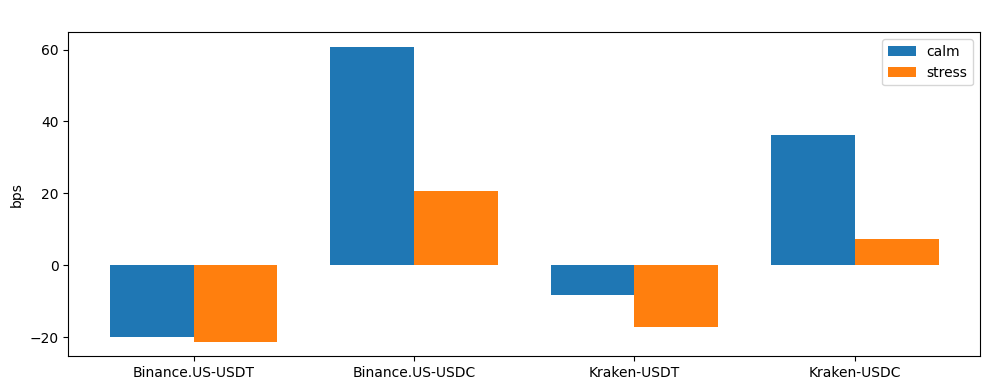

In [7]:
import matplotlib.pyplot as plt
import numpy as np

mean = {
    ("Binance.US", "USDT", "calm"): -19.8,  ("Binance.US", "USDT", "stress"): -21.2,
    ("Binance.US", "USDC", "calm"):  60.7,  ("Binance.US", "USDC", "stress"):  20.7,
    ("Kraken",  "USDT", "calm"):  -8.3,  ("Kraken",  "USDT", "stress"): -17.1,
    ("Kraken",  "USDC", "calm"):  36.3,  ("Kraken",  "USDC", "stress"):   7.4,
}


def grouped_bar_two_regimes(metric_dict, title, ylabel, outname, use_log=False):
    """
    Bars for calm vs stress for each series: Binance-USDT, Binance-USDC, Kraken-USDT, Kraken-USDC
    """
    series = [("Binance.US","USDT"), ("Binance.US","USDC"), ("Kraken","USDT"), ("Kraken","USDC")]
    labels = [f"{ex}-{coin}" for ex, coin in series]
    calm_vals = [metric_dict[(ex,coin,"calm")] for ex, coin in series]
    stress_vals = [metric_dict[(ex,coin,"stress")] for ex, coin in series]

    x = np.arange(len(labels))
    w = 0.38

    plt.figure(figsize=(10,4))
    plt.bar(x - w/2, calm_vals, width=w, label="calm")
    plt.bar(x + w/2, stress_vals, width=w, label="stress")
    plt.xticks(x, labels, rotation=0)
    plt.title(title)
    plt.ylabel(ylabel)
    if use_log:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    #plt.savefig(outname, dpi=300)
    #plt.close()
    plt.show()

# Fig B: Mean calm vs stress
grouped_bar_two_regimes(
    mean,
    title=" ",
    ylabel="bps",
    outname="figB_mean_calm_vs_stress.png",
    use_log=False
)
